<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

# Hypothesis Testing <a class="tocSkip">

Once a sample has been collected and described, the next step is to assume that the data follows a **parametric distribution**. A parametric distribution is a probability model described by a small number of parameters.

We use that model to make **decisions** under uncertainty.

In this notebook we will see:
- the three workhorse distributions of data (**Normal**, **Binomial**, **Poisson**),
- how to **fit** a distribution to a sample and **judge** whether the fit is acceptable,
- the **bootstrap** as a heuristic alternative when no theoretical distribution is available,
- the **hypothesis testing** framework: $H_0$, $H_1$, test statistic, decision rule,
- the two errors a test can make — **Type I** and **Type II** — and the trade-off between them,
- what a **p-value** actually means, and what it does **not** mean.

# Setup

In [1]:
#!pip install  --quiet

In [2]:
import requests

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/colab/clone_and_cd_colab.py"
colab = requests.get(url).text
exec(colab)

Running locally, skipping Colab setup.


In [3]:
import requests

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/styles/plot_style.py"
style = requests.get(url).text
exec(style)

Imported matplotlib.
Imported seaborn.
Plotting style set.


# What is Hypothesis Testing

<div style="border-left: 5px solid #4CAF50; background-color: #e8f5e9; padding: 10px; border-radius: 4px; color: inherit;">

A **hypothesis test** checks a claim about the **data-generating** process.

The claim may refer to:

- a **parameter**, such as $\mu$ (_mean_), $\lambda$ (_rate_), $\sigma^2$, or $\beta_1$;
- a **function of parameters**, such as $\mu_1 - \mu_2$, $\sigma_1^2 / \sigma_2^2$, or $\beta_1 - \beta_2$;
- a **population feature** not tied to a specific parametric model, such as a median, a quantile, or a rank-based location;
- the **shape of the distribution**, such as "the data are Normally distributed";
- the **relationship between variables**, such as independence, association, or equal distributions across groups.

Since we only observe a sample, we compute a **statistic** from the **sample** and ask:

> _Is the observed value plausible if the claim were true?_

</div><br>

**Special case: fitted models** — When we fit a parametric model, the fitted parameters are **estimates** computed from the sample.

> _They are **statistics** in the formal sense, because they are computed from the sample._

$\rightarrow$ They can be used in a hypothesis test, for example $\hat{\lambda}$ for a Poisson rate $\lambda$ or $\hat{\beta}_1$ for a regression slope $\beta_1$.

# From Data to a Theoretical Distribution

Real data is **noisy**.<br>
_Two days never look identical: the number of fraud alerts changes, the daily return changes, the count of approved cards changes._

Yet we cannot model every wiggle. We need a **summary** that compresses the noise into a small set of numbers — **a parametrized distribution**.

A **theoretical probability distribution** is a mathematical recipe with one or two parameters that produces a shape the data is supposed to come from.

Once we believe a distribution **fits**, we can:
- compute the **probability of unseen events** (e.g. *more than ten fraud alerts in an hour*);
- generate **synthetic** data with the same statistical character (_sampling_);
- run **hypothesis tests** in closed form.

The chain is:

$$ \text{empirical sample} \quad\longrightarrow\quad \text{candidate distribution } \mathcal{D}(\boldsymbol{\theta}) \quad\longrightarrow\quad \hat{\boldsymbol{\theta}} \quad\longrightarrow\quad \text{decisions} $$

where $\boldsymbol{\theta}$ is the parameter vector of the distribution and $\hat{\boldsymbol{\theta}}$ is its **estimate** from the sample.

_Let's see a few notable examples of common distributions._

<table><tr>
    <td width=900>
        <img src="images/fig_distributions_panorama.png" width="900">
    </td>
</tr></table>

<table><tr>
    <td width=900>
        <center>
            <br>
            Figure 1. The three workhorse distributions of banking data — Normal, Binomial, Poisson — with the kind of metric each one typically describes.
        </center>
    </td>
</tr></table>

## Normal Distribution

The **Normal** distribution is the default assumption whenever a quantity:
- is **continuous**
- can take **negative or positive** values
- is **roughly symmetric**

<div style="border: 2px solid #ddd; border-radius: 8px; padding: 15px; background-color: #f9f9f9;">

The **probability density function** of a Normal random variable with mean $\mu$ and variance $\sigma^{2}$ is:

$$ f(x \mid \mu, \sigma^{2}) = \frac{1}{\sqrt{2\pi\sigma^{2}}} \exp\!\left[-\frac{(x - \mu)^{2}}{2\sigma^{2}}\right] \tag{1} $$

where:
- $\mu$ is the **location** (mean and median);
- $\sigma$ is the **scale** (standard deviation).

</div>


<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff">

The MLE of the mean and variance from a sample $x_{1}, \dots, x_{n}$ are the familiar:

$$ \hat{\mu} = \frac{1}{n}\sum_{i=1}^{n} x_{i}, \qquad \hat{\sigma}^{2} = \frac{1}{n}\sum_{i=1}^{n} (x_{i} - \hat{\mu})^{2}. \tag{2}$$

</div>

Let's simulate one **trading year** of an equity index.<br>
We fit a Normal, and overlay the fitted density on the empirical histogram.

sample size n = 252
mu_hat    = -0.00013  (true +0.00040)
sigma_hat = 0.01029   (true 0.01100)


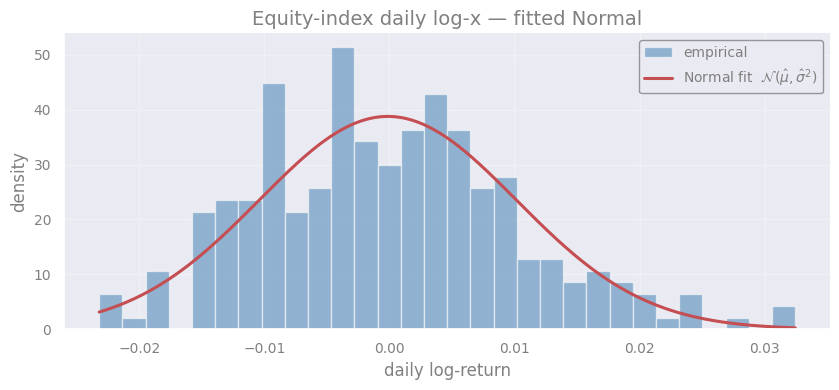

In [20]:
# ── Simulate one year (252 trading days) of log-x ───────────────────
n = 252
true_mu, true_sigma = 0.0004, 0.011    # ~ 10 bps drift, 1.1% daily vol

rng = np.random.default_rng(seed=42)
x = rng.normal(true_mu, true_sigma, size=n)

# MLE fit
mu_hat = x.mean()
sigma_hat = x.std(ddof=0)

print(f"sample size n = {n}")
print(f"mu_hat    = {mu_hat:+.5f}  (true {true_mu:+.5f})")
print(f"sigma_hat = {sigma_hat:.5f}   (true {true_sigma:.5f})")

# Plot
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.hist(x, bins=30, density=True, alpha=0.55,
        color="steelblue", edgecolor="white", label="empirical")

x = np.linspace(x.min(), x.max(), 400)
ax.plot(x, stats.norm.pdf(x, mu_hat, sigma_hat),
        color="C3", lw=2.2, label=fr"Normal fit  $\mathcal{{N}}(\hat\mu, \hat\sigma^{{2}})$")

ax.set_xlabel("daily log-return")
ax.set_ylabel("density")
ax.set_title("Equity-index daily log-x — fitted Normal")
ax.legend()
plt.show()

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff">


Real returns typically have <strong>fatter tails</strong> than the Normal, which is the entire reason Vector Autoregression (VAR) models built on Normality underestimate large losses.

</div>


## Binomial Distribution

The **Binomial** distribution describes the probability to count **$k$ successes**:
- in a **fixed** number **$n$** of independent trials,
- **each** with success probability **$p$**.

It applies whenever the answer is yes / no / yes / yes / no, and the $n$ trials are exchangeable.

<div style="border: 2px solid #ddd; border-radius: 8px; padding: 15px; background-color: #f9f9f9;">

The **probability mass function** (**pmf**) of a Binomial random variable is:

$$ P(K = k \mid n, p) = \binom{n}{k} p^{k} (1 - p)^{n - k}, \quad k \in \{0, 1, \dots, n\} \tag{3}$$

with mean and variance:

$$ \mathbb{E}[K] = n\,p, \qquad \mathrm{Var}[K] = n\,p\,(1 - p). $$

</div>


<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff">

The MLE of $p$ when $n$ is known is the **observed approval rate**:

$$ \hat{p} = \frac{k_{\text{obs}}}{n}. \tag{4}$$


For $D$ i.i.d. observations $k_{1}, \dots, k_{D}$, each drawn from $\mathrm{Bin}(n, p)$, the pooled MLE is:

$$ \hat{p} \;=\; \frac{1}{D\,n}\sum_{d=1}^{D} k_{d} \;=\; \frac{\bar{k}}{n}, \tag{5}$$

where $\bar{k}$ is the sample mean of the observed counts.

</div>

Let's simulate $D = 30$ days of **card-not-present** queries.<br>
Every day represents an i.i.d. observation or $n=100$ requests.<br>

We fit a Binomial, and overlay the fitted pmf on the empirical histogram.

days    = 30
k       = [ 90 93 89 ... 96 95 91 ]
k avg   = 91.50
n       = 100
p_hat = average k / n = 0.9150    (true 0.9200)


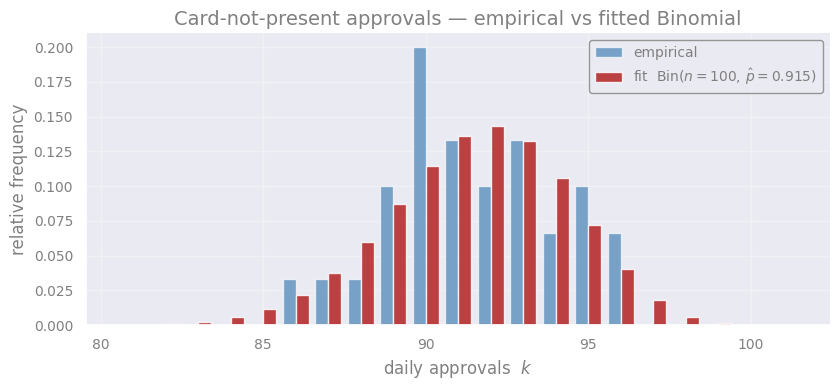

In [4]:
# ── Sample 30 trading days at a merchant: 100 CNP requests per day ────────
D     = 30
n = 100
true_p     = 0.92  # 92% baseline approval rate

rng = np.random.default_rng(seed=42)
k_d = rng.binomial(n, true_p, size=D)  # draw D observations

p_hat = k_d.mean() / n      # pooled MLE

print(f"days    = {D}")
print(f"k       = [", *k_d[:3], "...", *k_d[-3:], "]")
print(f"k avg   = {k_d.mean():.2f}")
print(f"n       = {n}")
print(f"p_hat = average k / n = {p_hat:.4f}    (true {true_p:.4f})")

# Empirical histogram of daily approvals vs fitted Bin(n, p_hat) pmf
k_grid  = np.arange(k_d.min() - 5, k_d.max() + 6)
emp     = np.array([(k_d == k).mean() for k in k_grid])
pmf_fit = stats.binom.pmf(k_grid, n, p_hat)

fig, ax = plt.subplots(figsize=(8.5, 4))
width = 0.4
ax.bar(k_grid - width/2, emp,     width=width, color="steelblue",  alpha=0.7,
       edgecolor="white", label="empirical")
ax.bar(k_grid + width/2, pmf_fit, width=width, color="firebrick",  alpha=0.85,
       edgecolor="white",
       label=fr"fit  $\mathrm{{Bin}}(n={n},\,\hat p={p_hat:.3f})$")
ax.set_xlabel(r"daily approvals  $k$")
ax.set_ylabel("relative frequency")
ax.set_title("Card-not-present approvals — empirical vs fitted Binomial")
ax.legend()
plt.show()

## Poisson Distribution

The **Poisson** distribution describes the count of **rare events** in a fixed window of time, space, or any other unit of exposure.<br>
_(When each event is independent of the others.)_


<div style="border: 2px solid #ddd; border-radius: 8px; padding: 15px; background-color: #f9f9f9;">

The Poisson **probability mass function** gives the probability to count $k$ events in the window, if the rate is $\lambda$:

$$ P(K = k \mid \lambda) = \frac{\lambda^{k} e^{-\lambda}}{k!}, \quad k \in \{0, 1, 2, \dots\} \tag{6}$$

with the unusual property:

$$ \mathbb{E}[K] = \mathrm{Var}[K] = \lambda. $$


_NOTE: **Mean equals variance** is a brittle assumption._<br>
> _If the empirical variance of the counts is much larger than the mean — a phenomenon called <strong>over-dispersion</strong> — the Poisson is the wrong model and we typically reach for a Negative Binomial instead. Always check the variance, not just the mean._

</div>


<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff">

The MLE is again the **sample mean** of the counts:

$$ \hat{\lambda} = \frac{1}{n}\sum_{i=1}^{n} k_{i}. \tag{7}$$

</div>

Let's simulate $D = 30$ days of **ATM out-of-service incidents**.<br>
Every day represents an i.i.d. observation of the daily incident count at one branch.<br>

We fit a Poisson, and overlay the fitted pmf on the empirical histogram.


sample mean     = 3.767    (true lambda = 2.7)
sample variance = 3.779    (Poisson predicts 3.767)


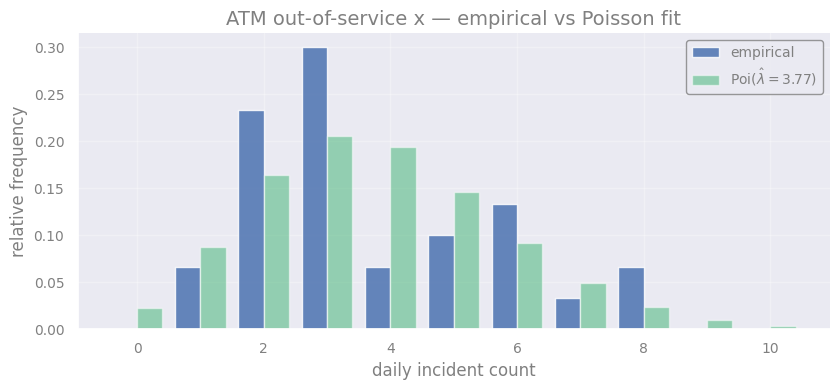

In [19]:
# ── 60 days of ATM out-of-service x at one branch ─────────────────
true_lambda = 2.7  # ~ 2.7 x per day on average
n = 30

rng = np.random.default_rng(seed=42)
x = rng.poisson(true_lambda, size=n) + 1  # draw n observations

lam_hat = x.mean()
var_hat = x.var(ddof=0)

print(f"sample mean     = {lam_hat:.3f}    (true lambda = {true_lambda})")
print(f"sample variance = {var_hat:.3f}    (Poisson predicts {lam_hat:.3f})")

# Empirical histogram vs theoretical pmf
k_grid = np.arange(0, max(x) + 3)
emp = np.array([(x == k).mean() for k in k_grid])
pmf_fit = stats.poisson.pmf(k_grid, lam_hat)

pmf_true = stats.poisson.pmf(k_grid, true_lambda)

fig, ax = plt.subplots(figsize=(8.5, 4))
width = 0.4
ax.bar(k_grid - width / 2, emp, width=width, color="C0", alpha=0.85,
       edgecolor="white", label="empirical")
ax.bar(k_grid + width / 2, pmf_fit, width=width, color="mediumseagreen", alpha=0.5,
       edgecolor="white", label=fr"$\mathrm{{Poi}}(\hat\lambda={lam_hat:.2f})$")

# ax.bar(k_grid + width / 2, pmf_true, width=width, color="C3", alpha=0.5,
#        edgecolor="white", label=fr"$\mathrm{{Poi}}(\lambda={true_lambda:.2f})$")

ax.set_xlabel("daily incident count")
ax.set_ylabel("relative frequency")
ax.set_title("ATM out-of-service x — empirical vs Poisson fit")
ax.legend()
plt.show()

sample mean     = 3.767    (true lambda = 2.7)
sample variance = 3.779    (Poisson predicts 3.767)


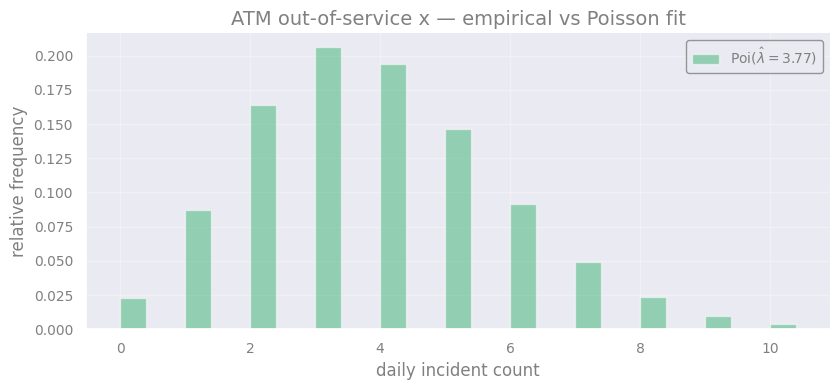

In [48]:
# ── 60 days of ATM out-of-service x at one branch ─────────────────
true_lambda = 2.7  # ~ 2.7 x per day on average
n = 30

rng = np.random.default_rng(seed=42)
x = rng.poisson(true_lambda, size=n) + 1  # draw n observations

lam_hat = x.mean()
var_hat = x.var(ddof=0)

print(f"sample mean     = {lam_hat:.3f}    (true lambda = {true_lambda})")
print(f"sample variance = {var_hat:.3f}    (Poisson predicts {lam_hat:.3f})")

# Empirical histogram vs theoretical pmf
k_grid = np.arange(0, max(x) + 3)
emp = np.array([(x == k).mean() for k in k_grid])
pmf_fit = stats.poisson.pmf(k_grid, lam_hat)

pmf_true = stats.poisson.pmf(k_grid, true_lambda)

fig, ax = plt.subplots(figsize=(8.5, 4))
width = 0.4
# ax.bar(k_grid - width / 2, emp, width=width, color="C0", alpha=0.85,
#        edgecolor="white", label="empirical")
ax.bar(k_grid + width / 2, pmf_fit, width=width, color="mediumseagreen", alpha=0.5,
       edgecolor="white", label=fr"$\mathrm{{Poi}}(\hat\lambda={lam_hat:.2f})$")

# ax.bar(k_grid + width / 2, pmf_true, width=width, color="C3", alpha=0.5,
#        edgecolor="white", label=fr"$\mathrm{{Poi}}(\lambda={true_lambda:.2f})$")

ax.set_xlabel("daily incident count")
ax.set_ylabel("relative frequency")
ax.set_title("ATM out-of-service x — empirical vs Poisson fit")
ax.legend()
plt.show()

# Diagnostic Plots — Does the Distribution Fit?

Estimating $\hat{\boldsymbol{\theta}}$ is "easy" $\rightarrow$ The hard question is whether the distribution you assumed is the **right one**.

Two staple diagnostics:

- For discrete data, plot the **empirical pmf** (relative frequencies) against the **theoretical pmf** with the fitted parameters.<br>
    _That is what we did just above._

- For continuous data, the **Q-Q plot** compares sample quantiles to the quantiles of the assumed distribution.<br>
    _Points on the diagonal mean the fit is good; systematic curvature reveals where the model fails._

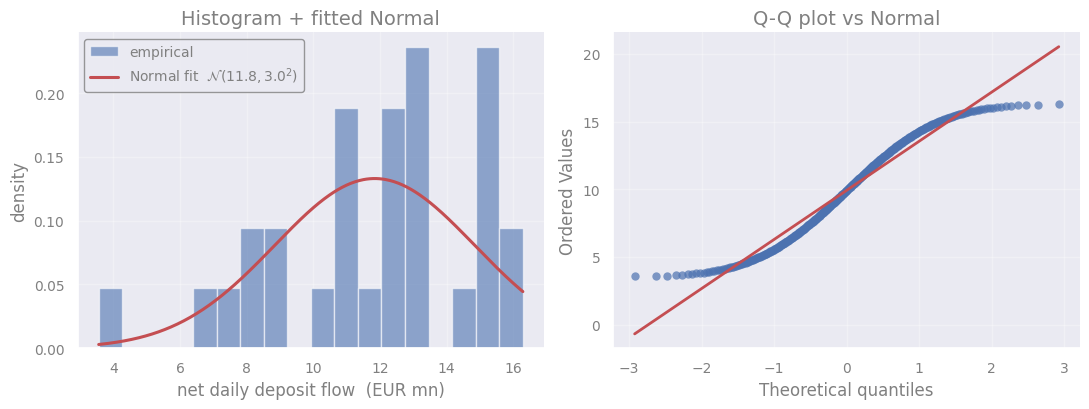

In [25]:
# ── Simulate net deposit flow (in EUR millions) — Normal-ish but with a small skew ──
n = 30
rng = np.random.default_rng(seed=42)
x = rng.normal(loc=12.0, scale=4.0, size=n)
x += 0.6 * rng.standard_t(df=4, size=n)   # mild fat tail

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Histogram + Normal fit
ax = axes[0]
ax.hist(x, bins=18, density=True, alpha=0.6,
        color="C0", edgecolor="white", label="empirical")
mu_hat, sigma_hat = x.mean(), x.std(ddof=0)
x = np.linspace(x.min(), x.max(), 400)
ax.plot(x, stats.norm.pdf(x, mu_hat, sigma_hat), color="C3", lw=2.2,
        label=fr"Normal fit  $\mathcal{{N}}({mu_hat:.1f}, {sigma_hat:.1f}^2)$")
ax.set_xlabel("net daily deposit flow  (EUR mn)")
ax.set_ylabel("density")
ax.set_title("Histogram + fitted Normal")
ax.legend()

# Q-Q plot
ax = axes[1]
stats.probplot(x, dist="norm", plot=ax)
ax.set_title("Q-Q plot vs Normal")
for child in ax.get_lines():
    if child.get_marker() == "o":
        child.set_markerfacecolor("C0")
        child.set_markeredgecolor("none")
        child.set_alpha(0.7)
    else:
        child.set_color("C3")

plt.show()

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff">

Light deviations at the extremes of the Q-Q plot are common and **do not** invalidate the Normal fit by themselves.

The questions to ask are:

- Are the deviations **systematic** across many days, or driven by 1–2 points?
- Are the tails **heavier** or **lighter** than the model predicts? (Heavier tails → underestimated risk.)

$\rightarrow$ **Hypothesis testing** allows to **quantify** what we may infer from the plots.

</div>

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

## Exercise [10 min]

**Objective:** Plot the empirical pmf of a Poisson sample and compare its centre with the **true value** $\lambda_0$.

**Setting:** A card-issuer monitoring desk records the number of **fraud alerts per hour**.

The true hourly rate is $\lambda_0 = 3.6$. We collect $n = 14 \times 24 = 336$ hours of data.

_In particular, you must:_

1. **Generate** the dataset using the cell provided right below — It uses `rng.poisson(true_lambda, size=n)` to draw the counts.
2. **Plot** the empirical pmf of the counts (use `plt.bar`).
3. **Mark** the expected value $\lambda_0 = 3.6$ on the plot as a single vertical line (use `plt.axvline`).
4. **Look at the plot:** is the empirical mass concentrated around $\lambda$, as theory predicts?

</div>

In [26]:
# ── Given data — do not change the seed ───────────────────────────────────
lambda_0 = 3.6  # true lambda
n = 14 * 24

rng = np.random.default_rng(seed=42)
x = rng.poisson(lambda_0, size=n)

In [271]:
# Student: Write your code here. Add blocks as you deem fit.

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[Solution below]</b>

</div>


In [36]:
print( (x == 0).sum()/n )

print( (x == 0).mean() )

0.02976190476190476
0.02976190476190476


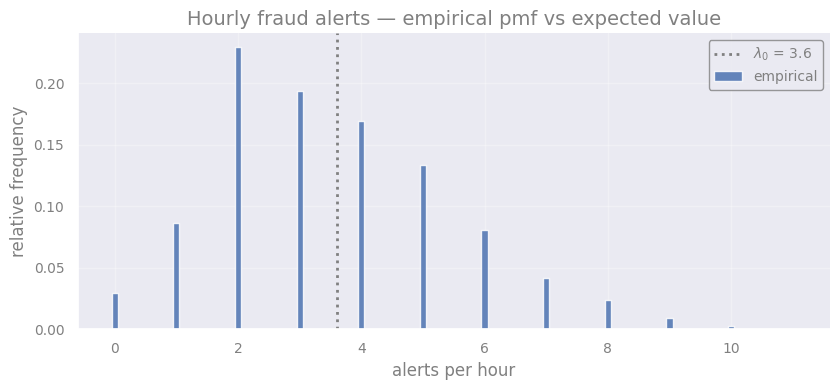

In [27]:
# Empirical pmf with the expected value lambda marked
k_grid = np.arange(0, x.max() + 2)
emp    = np.array([(x == k).mean() for k in k_grid])

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(k_grid, emp, color="C0", alpha=0.85, edgecolor="white", label="empirical", width=0.1)
ax.axvline(lambda_0, color="gray", lw=2, ls=":",
           label=fr"$\lambda_0$ = {lambda_0}")
ax.set_xlabel("alerts per hour")
ax.set_ylabel("relative frequency")
ax.set_title("Hourly fraud alerts — empirical pmf vs expected value")
ax.legend()
plt.show()

**Comment:**

The empirical bars cluster around the dashed line at $\lambda_{0} = 3.6$ — the peak sits at $k = 2{-}3$ and the bulk of the mass spans 1 to 5. The right tail thins out gradually past the line, the typical right-skewed Poisson signature.

The sample's centre lands close to $\lambda_{0}$ — consistent with theory.


<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[End of solution]</b>

</div>


# The Hypothesis Testing Framework

Once we believe data follows a known distribution, we can ask **decision questions** of the form:

> _Is the observed data compatible with a working claim about $\theta$, or unusual enough that we should reject it?_

Hypothesis testing is the disciplined way to answer that question with a **probability of being wrong** attached to it.

<div style="border: 2px solid #ddd; border-radius: 8px; padding: 15px; background-color: #f9f9f9;">

**Formal framework**

We never prove the claim true, but assess when the data deviates from it strongly **enough to reject it** $\dots$<br>

$\dots$ while keeping the **probability of falsely rejecting** bounded by a level **$\alpha$** chosen up front.

</div>
<br>

The _whole process_ is outlined in the following image, and described in the remainder:

<table><tr>
    <td width=900>
        <img src="images/fig_hypothesis_flow.png" width="900">
    </td>
</tr></table>

<table><tr>
    <td width=900>
        <center>
            Figure 2. The four-step recipe of any hypothesis test — state, choose a test, compute, decide.
        </center>
    </td>
</tr></table>

## Null and Alternative Hypothesis

Any test starts with two mutually-exclusive statements about the world.

- The **null hypothesis** $H_{0}$ encodes the *status quo* — the claim we are willing to keep if the data does not strongly contradict it.
- The **alternative hypothesis** $H_{1}$ encodes the *challenger* — the claim we accept only if the data points clearly away from $H_{0}$.

The test is **conservative**: $H_{0}$ is innocent until proven guilty.



One more sub-category — **One/Two-sided** tests:

- Two-sided $H_{1}$ asks *is the parameter different?*
- One-sided $H_{1}$ asks *is the parameter larger / smaller?*

<div style="border-left: 4px solid #9C27B0; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; background-color: #f6f2fa; margin-top: 1em;">

<strong>Business Lens — Picking $H_0$ in banking.</strong>

$\rightarrow$ Pick the null so that <em>incorrectly rejecting it</em> is the **more expensive** mistake.

_Examples:_

- If you are evaluating a change to a fraud rule:<br>
  > $H_0$ should be $\rightarrow$ "the new rule does not differ from the baseline"
    
  _(You do not want to roll out a fake improvement)_

- If you are evaluating an Service Level Agreement (SLA) breach:<br>
    
    > $H_0$ should be $\rightarrow$ "the SLA is met"
    
    _(You do not want to falsely accuse the vendor)_

</div>

## Test Statistics and Rejection Regions

<div style="border: 2px solid #ddd; border-radius: 8px; padding: 15px; background-color: #f9f9f9;">

A **test statistic** is a function of the sample — let's call it $T$ — chosen so that:
- under $H_{0}$, the distribution of $T$ is **known**;
- under $H_{1}$, $T$ tends to take **larger** (in absolute value) values.

Given a **significance level** $\alpha$ (commonly 0.05 or 0.01), the **rejection region** is the set of $T$ values that are unlikely enough under $H_{0}$ that we would rather reject:

$$ R_{\alpha} = \{\, t : P(\,|T| \geq |t|\, \mid H_{0}) \leq \alpha \,\}. \tag{8}$$

</div>

## Example: Silence at the fraud desk

Under normal operating conditions the fraud-monitoring system raises $\lambda_{0} = 2$ alerts per hour — one every **30 minutes** on average.

During a market stress event the desk observes a silence of $x_{\rm obs} = 1.2$ hours: no alert fires.

**Q:** Is this silence just a run of normal luck — or is the alert rate genuinely lower than usual?

**A:** _Let's follow the recipe of Figure 2 $\dots$_

<br>

In [40]:
lam0  = 2.0   # baseline alert rate (alerts / hour)
x_obs = 1.2   # observed silence (hours)

### Step 1.A — State the hypotheses

- $H_{0}:\; \lambda = \lambda_{0}$ — the alert rate matches the baseline.
- $H_{1}:\; \lambda < \lambda_{0}$ — one-sided alternative: the system is **quieter than normal**.

### Step 1.B — Choose the significance level

We fix $\alpha = 0.05$ up front.

What this implies? $\rightarrow$ Under $H_{0}$ we accept a 5% long-run rate of falsely flagging a normal silence as anomalous.

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff">

Are you ok with 5%?

Or would you prefer a more stringent significance level?

Write down your choice in the cell below.

Be warned: **you cannot change this later.**

</div>

In [41]:
alpha = 0.05

### Step 2.A — Pick a test statistic

We take the simplest possible choice: the **observed gap itself**,

$$ T \;=\; X, $$

where $X$ is the duration (in hours) from the last alert to now.

### Step 2.B — Assume the statistic PDF

We **assume** the gap between alerts follows an exponential distribution — Under $H_{0}$ its rate is $\lambda_{0}$, so its **PDF** is:

$$ p(x \mid \lambda_{0}) \;=\; \lambda_{0} e^{-\lambda_{0} x}, \quad x \geq 0. \tag{9} $$

### Step 3 — Compute the p-value

A **long** silence is evidence against $H_{0}$ $\rightarrow$ p-value is the right-tail probability under the null:

$$ p_{\rm value} \;=\; P(X \geq x_{\rm obs} \mid \lambda_{0}) \;=\; \int_{x_{\rm obs}}^{\infty} \lambda_{0}\, e^{-\lambda_{0} x}\, dx \;=\; e^{-\lambda_{0}\, x_{\rm obs}}. \tag{10}$$

Graphically, the p-value is the area under the pdf to the **right** of $x_{\rm obs}$.

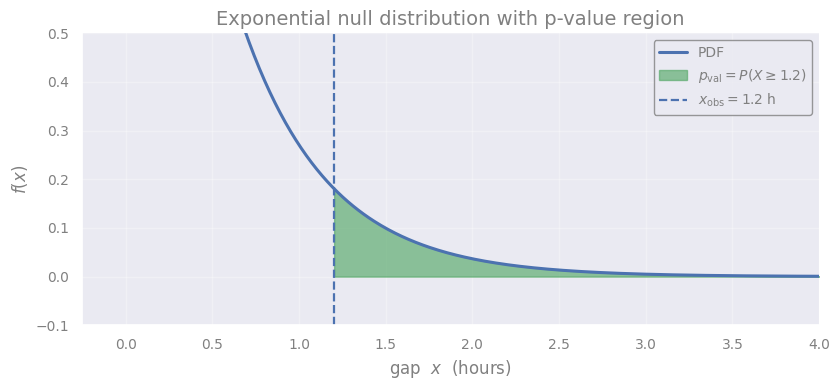

In [47]:
# ── Exponential null distribution and p-value region ─────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x   = np.linspace(0, 5, 500)
pdf = stats.expon.pdf(x, scale=1 / lam0)

fig, ax = plt.subplots(figsize=(8.5, 4))

ax.plot(x, pdf, color="C0", lw=2.2,
        label=r"PDF")

mask = x >= x_obs
ax.fill_between(x[mask], pdf[mask], alpha=0.65, color="C2",
                label=fr"$p_{{\rm val}} = P(X \geq {x_obs:.1f})$")

ax.axvline(x_obs, color="C0", ls="--", lw=1.6,
           label=fr"$x_{{\rm obs}} = {x_obs:.1f}$ h")

# # rejection region (red)
# mask_a = x >= x_alpha
# ax.fill_between(x[mask_a], pdf[mask_a], alpha=0.45, color="firebrick",
#                 label=fr"$\alpha = {alpha}$ region  ($x_\alpha = {x_alpha:.2f}$ h)")

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.set_xlabel("gap  $x$  (hours)")
ax.set_ylabel(r"$f(x)$")
ax.set_title("Exponential null distribution with p-value region")
ax.set_xlim([None, 4])
ax.set_ylim([None, 0.5])
ax.legend()
plt.show()

We can compute the p-value directly from Equation 10:

In [45]:
import numpy as np

p_val = np.exp(-lam0 * x_obs)  # closed form

print(f"p-value: {p_val:.4f}")

p-value: 0.0907


### Step 4 — Apply decision

Reject $H_{0}$ if $p_{\rm val} < \alpha$.

This is the **exact exponential test** — the simplest possible hypothesis test on a continuous distribution, with the reference distribution read straight off the pdf.

In [46]:
if p_val < alpha:
    print(f"p_val ({p_val:.4f}) < alpha ({alpha}) -> reject H0")
else:
    print(f"p_val ({p_val:.4f}) >= alpha ({alpha}) -> do NOT reject H0")

p_val (0.0907) >= alpha (0.05) -> do NOT reject H0


<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff">

**REMEMBER:** Failing to reject is not the same as proving $H_0$ true!

</div>

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

## Exercise [15 min]

**Objective:** Apply the four-step recipe to a simple test whose statistic has a **Gaussian** PDF under $H_{0}$.

**Setting:** A monitoring system reports one number per day. Under normal operation the number is Gaussian with known mean $\mu_{0} = 50$ and known standard deviation $\sigma = 10$.

Today we observe $x_{\rm obs} = 70$. Is this unusually high?

_In particular, you must:_

1. **State** $H_{0}: \mu = \mu_{0}$ and $H_{1}: \mu > \mu_{0}$ (one-sided, right tail).
2. **Pick** the test statistic $T = X$ — the observation itself. Under $H_{0}$ its PDF is $p(x \mid \mu_{0}, \sigma)$, a Gaussian with mean $\mu_{0}$ and standard deviation $\sigma$.
3. **Compute** the p-value $P(X \geq x_{\rm obs} \mid H_{0})$ using `scipy.stats.norm.sf`.
4. **Decide** at $\alpha = 0.05$ and state the conclusion in plain language.

</div>

In [209]:
# ── Given values — do not change them ─────────────────────────────────────
mu0   = 50.0
sigma = 10.0
x_obs = 70.0
alpha = 0.05

In [210]:
# Student: Write your code here. Add blocks as you deem fit.

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[Solution below]</b>

</div>

In [211]:
# ── Solution ──────────────────────────────────────────────────────────────
from scipy import stats

p_val = stats.norm.sf(x_obs, loc=mu0, scale=sigma)
print(f"p-value = {p_val:.4f}")

if p_val < alpha:
    print(f"p_val ({p_val:.4f}) < alpha ({alpha}) -> reject H0")
else:
    print(f"p_val ({p_val:.4f}) >= alpha ({alpha}) -> do NOT reject H0")

p-value = 0.0228
p_val (0.0228) < alpha (0.05) -> reject H0


**Comment:**

The observed value sits 2 standard deviations above the mean — well into the right tail.

The p-value is about 0.023, below $\alpha = 0.05$, so we **reject** $H_{0}$ $\rightarrow$ The observation is statistically inconsistent with normal operation.

# Type I and Type II Errors

Every test can be wrong in 2 distinct ways.

- **Type I error.** Reject $H_{0}$ when it is in fact true.<br>
  _The probability of this happening is exactly $\alpha$, the significance level we chose._
  
- **Type II error.** Fail to reject $H_{0}$ when it is in fact false.<br>
  _The probability of this happening is called $\beta$ and depends on the **true** value of the parameter under $H_{1}$._

<div style="border: 2px solid #ddd; border-radius: 8px; padding: 15px; background-color: #f9f9f9;">

The complement of $\beta$ is the **power** of the test:

$$ \text{Power} = 1 - \beta = P(\text{reject } H_{0} \mid H_{1}\text{ true}). \tag{11}$$

</dev>

<table><tr>
    <td width=900>
        <img src="images/fig_type_errors.png" width="900">
    </td>
</tr></table>

<table><tr>
    <td width=900>
        <center>
            <br>
            Figure 3. The two errors share one cut-off. Lowering $\alpha$ shrinks the red zone but enlarges the violet zone. Only a larger sample shrinks both at once.
        </center>
    </td>
</tr></table>

Useful rules of thumb for sample size:

- A larger $n$ shrinks the standard error of $\hat{\theta}$ $\rightarrow$ sharpens both distributions $\rightarrow$ **increases power** at any fixed $\alpha$.
- A smaller effect size (the gap between the true parameter and the null value) requires a larger $n$ to detect at a given power.
- Power calculations should happen **before** the test, not after.

## How does power change with the true parameter value?

**Following on the example above $\dots$**

- The Type-I rate is fixed at $\alpha$ by construction.

- The Type-II rate $\beta$ — and therefore the **power** $1 - \beta$ — depend on **where the unknown true rate $\lambda$ actually lies** relative to $\lambda_{0}$.

Below we fix $\alpha = 0.05$ and trace the power as a function of the unknown true $\lambda$.

The **critical threshold** is the gap length beyond which we reject $H_{0}$:

$$ x_{\alpha} \;=\; \frac{-\ln \alpha}{\lambda_{0}}. $$

The **power** at any unknown true $\lambda$ is then:

$$ \text{Power}(\lambda) \;=\; P(X \geq x_{\alpha} \mid \lambda) \;=\; e^{-\lambda\, x_{\alpha}}. $$

When $\lambda = \lambda_{0}$, the power equals $\alpha$ — by construction we reject $H_{0}$ only 5% of the time.

As $\lambda$ falls below $\lambda_{0}$ (silences become typically longer), the power climbs toward $1$ $\rightarrow$ the true slowdown becomes harder to miss.

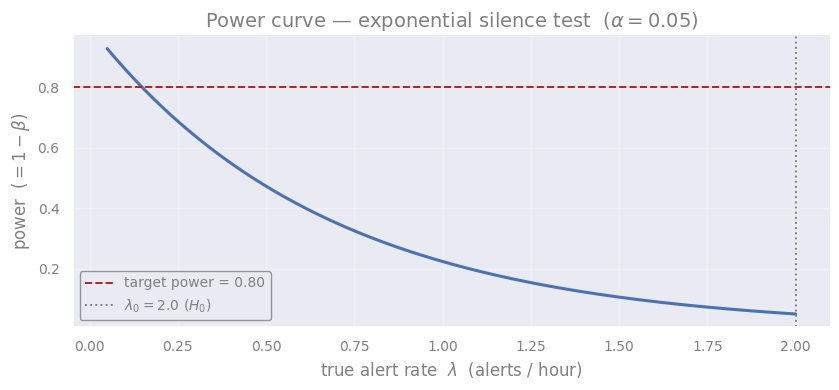

In [49]:
# ── Power curve for the exponential silence test ──────────────────────────
lam0    = 2.0
alpha   = 0.05

x_alpha = -np.log(alpha) / lam0                 # critical threshold (hours)

lam_grid = np.linspace(0.05, 2.0, 300)
power    = np.exp(-lam_grid * x_alpha)          # Power(lambda) = e^{-lambda * x_alpha}

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(lam_grid, power, color="C0", lw=2.2)
ax.axhline(0.8,  color="firebrick", ls="--", lw=1.4, label="target power = 0.80")
ax.axvline(lam0, color="gray",      ls=":",  lw=1.4, label=fr"$\lambda_0 = {lam0}~(H_{0})$")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.set_xlabel(r"true alert rate  $\lambda$  (alerts / hour)")
ax.set_ylabel(r"power  $(= 1 - \beta)$")
ax.set_title(fr"Power curve — exponential silence test  ($\alpha = {alpha}$)")
ax.legend()
plt.show()

# Bootstrap Hypothesis Tests

Every test seen so far rests on a **theoretical** reference PDF for the test statistic under $H_{0}$.<br>

That ingredient is not always available $\rightarrow$ 2 situations where the theoretical PDF is **missing**:

- The statistic of interest is **non-standard** — _e.g., a median, a quantile, a trimmed mean, a Sharpe ratio, a custom risk indicator._<br>

- The data clearly violates the **assumptions** of the standard test — _heavy tails, strong asymmetry, very small $n$, or dependence_ — so the theoretical reference PDF is not trustworthy _even_ when it exists.

The **bootstrap** sidesteps the problem by building the reference distribution **directly from the data**.

> _It is a **heuristic** procedure: it treats the empirical sample as a proxy for the population and resamples from it._


<div style="border: 2px solid #ddd; border-radius: 8px; padding: 15px; background-color: #f9f9f9;">

**Bootstrap one-sample test** for a generic statistic $\hat{T}$ with null $H_{0}: T = T_{0}$:

1. Compute $\hat{T}_{\rm obs}$ on the original sample $\{x_{1}, \dots, x_{n}\}$.

2. **Shift the sample** so that the null holds — produce $\{x_{i}^{\prime}\}$ such that the statistic evaluated on it equals $T_{0}$.<br>
_For tests on a centre, this is $x_{i}^{\prime} = x_{i} - \hat{T}_{\rm obs} + T_{0}$._

4. Draw $B$ samples of size $n$ with replacement from $\{x_{i}^{\prime}\}$; on each, compute $\hat{T}_{b}^{*}$.

5. The collection $\{\hat{T}_{1}^{*}, \dots, \hat{T}_{B}^{*}\}$ is the bootstrap reference distribution **under $H_{0}$**.

6. The two-sided p-value is the empirical tail mass beyond the observed deviation:

$$ p_{\rm value} \;\approx\; \frac{1}{B}\sum_{b=1}^{B} \mathbf{1}\!\left[\,\bigl|\hat{T}_{b}^{*} - T_{0}\bigr| \;\geq\; \bigl|\hat{T}_{\rm obs} - T_{0}\bigr|\,\right]. \tag{12}$$

</div>

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff">

The **price**: we lose the clean theoretical guarantee — bootstrap works because of asymptotic results and accumulated empirical evidence.

The **reward**: it works for almost any statistic, on almost any data, with the same handful of lines of code.

</div>

## Example: median monthly transactions per active retail customer

Suppose we know the **median** monthly transaction count for active retail customers is: $m_{0} = 18$.

The product team pulls a fresh sample of 60 customers and asks whether the true median has changed.

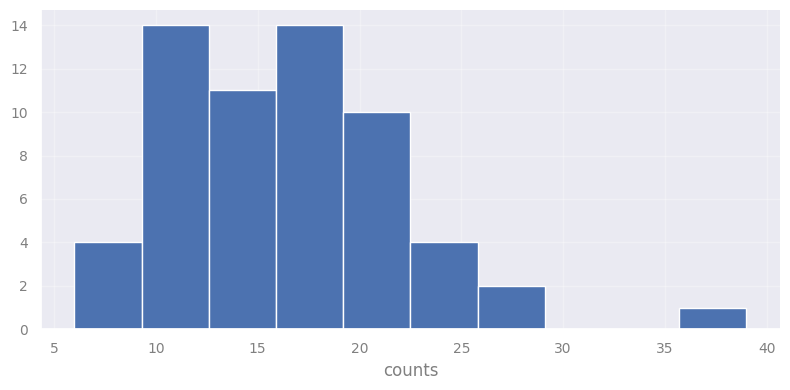

sample median  = 16.00
benchmark m0   = 18
observed gap   = -2.00


In [54]:
# ── Sample of 60 active retail customers — slightly skewed counts ─────────
n = 60

rng = np.random.default_rng(seed=42)
x = rng.lognormal(mean=np.log(15), sigma=0.45, size=n).round().astype(int)  # sample some data
'''
The lognormal is the Generative Process of the observed data for this example.
It may or may not have a true median compatible m_0, we will check exactly this.
''';

plt.hist(x, bins=10)
plt.xlabel('x')
plt.xlabel('counts')
plt.show()

m0 = 18
m_obs = float(np.median(x))

print(f"sample median  = {m_obs:.2f}")
print(f"benchmark m0   = {m0}")
print(f"observed gap   = {m_obs - m0:+.2f}")

The sampling distribution of the median has no clean closed form for $n = 60$, and the data is mildly skewed.<br>
$\rightarrow$ _We hit both of the 2 conditions that makes bootstrapping shine!_

Let's derive 10,000 **bootstrapped samples**, then apply Equation 12 to get the **p-value**.

In [67]:
# ── Bootstrap null distribution of the median ─────────────────────────────
B = 10_000  # Run on 10,000 bootstrapped samples
x_shifted = x - m_obs + m0          # enforce H0 on the resampling pool

boot_idx = rng.integers(0, n, size=(B, n))
boot_samples = x_shifted[boot_idx]
boot_T = np.median(boot_samples, axis=1)

We can also visualize our **empirical PDF for the median**.

This is simply the **histogram** of the 10,000 medians measured on the 10,000 bootstrapped samples!

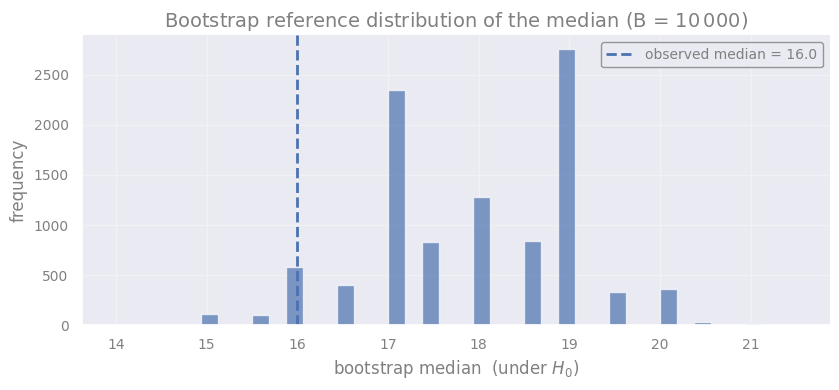

In [66]:
# Visualise the bootstrap reference distribution
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.hist(boot_T, bins=40, color="C0", alpha=0.7, edgecolor="white")
ax.axvline(m_obs, color="C0", lw=2, ls='--', label=f"observed median = {m_obs:.1f}")
# ax.axvline(m0, color="gray", lw=1.4, ls=":", label=fr"$m_0 = {m0}$")
ax.set_xlabel("bootstrap median  (under $H_0$)")
ax.set_ylabel("frequency")
ax.set_title(r"Bootstrap reference distribution of the median (B = 10$\,$000)")
ax.legend()
plt.show()

In [70]:
# Two-sided bootstrap p-value
p_boot = np.mean(np.abs(boot_T - m0) >= abs(m_obs - m0))
print(f"bootstrap p-value (two-sided) = {p_boot:.4f}")

bootstrap p-value (two-sided) = 0.1217


<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff">

The reference PDF was **built from the data itself**.

<u>Whatever</u> the shape of the underlying population, the bootstrap approximates the PDF of the statistic <em>as if</em> it were drawn from that population.

</div>


<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff">

**Curiosity**

For a difference between two groups, the natural counterpart is a <strong>permutation test</strong>: pool the two samples, shuffle the labels, recompute the statistic of interest, repeat $B$ times. The shuffle enforces the null "there is no difference between groups". A two-sample bootstrap variant resamples each group separately and tracks the difference of statistics across the resamples.

</div>


## Caveats — the bootstrap is not magic.

It **inherits the limits of the sample** $\rightarrow$ A small or biased sample produces a small or biased reference distribution.

- It is **unsuitable** for statistics dominated by the **extremes** (_maximum, minimum_), where resampling cannot create new tail behaviour.
  
- It assumes **independent** observations. Time-series and clustered data require block or stratified bootstrap variants.

- The number of resamples $B$ controls the **resolution** of the p-value $\leftarrow$ $B = 10\,000$ resolves p-values down to about $10^{-4}$.

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

## Exercise [40 min]

**Objective:** Run a bootstrap hypothesis test on the **mean** of a heavy-tailed distribution.

**Setting:** A retail bank tracks **monthly fee revenue per branch** as a performance metric. The business plan sets an internal baseline of $\mu_{0} = 60$ (EUR thousand) per branch.

We have one month of data covering **180 branches** and want to test whether the true mean is **above** the baseline.

_In particular, you must:_

1. **Generate** the dataset using the cell provided right below — do **not** change the seed.
2. **Compute** the observed sample mean $\bar{x}$.
3. **State** $H_{0}$ and $H_{1}$, choose a **one-sided** alternative ($H_{1}: \mu > \mu_{0}$).
4. **Build** the bootstrap reference distribution of the mean under $H_{0}$ with $B = 10\,000$ resamples. Use the shift $x_{i}^{\prime} = x_{i} - \bar{x} + \mu_{0}$ to enforce the null on the resampling pool.
5. **Compute** the one-sided bootstrap p-value.
6. **Plot** the bootstrap null distribution with $\bar{x}$ and $\mu_{0}$ marked.
7. **Decide** at $\alpha = 0.05$ and report the conclusion in plain language.

</div>

In [75]:
# ── Given data — do not change the seed ───────────────────────────────────
n = 180

exercise_rng = np.random.default_rng(seed=2604_4003)
x = exercise_rng.lognormal(mean=np.log(60), sigma=0.55, size=n)

print(f"n branches = {n}")
print(f"sample mean   = {x.mean():.1f}  (EUR k)")
# print(f"sample median = {np.median(x):.1f}  (EUR k)")

n branches = 180
sample mean   = 70.3  (EUR k)


In [74]:
x.shape

(180,)

In [198]:
# Student: Write your code here. Add blocks as you deem fit.

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[Solution below]</b>

</div>


In [199]:
# ── Solution ──────────────────────────────────────────────────────────────
# H0: mu = 60     H1: mu > 60     (one-sided, right tail)

mu0    = 60.0
x_bar  = float(x.mean())

print(f"observed sample mean = {x_bar:.2f}  (EUR k)")
print(f"baseline mu0         = {mu0:.2f}")
print(f"observed gap         = {x_bar - mu0:+.2f}")

observed sample mean = 70.26  (EUR k)
baseline mu0         = 60.00
observed gap         = +10.26


In [200]:
# ── Bootstrap null distribution of the sample mean ────────────────────────
B = 10_000
shifted = x - x_bar + mu0     # enforce H0 on the resampling pool

boot_idx     = exercise_rng.integers(0, n, size=(B, n))
boot_samples = shifted[boot_idx]
boot_T       = boot_samples.mean(axis=1)

p_boot = np.mean(boot_T >= x_bar)            # one-sided, right tail
print(f"bootstrap p-value (one-sided) = {p_boot:.4f}")

bootstrap p-value (one-sided) = 0.0026


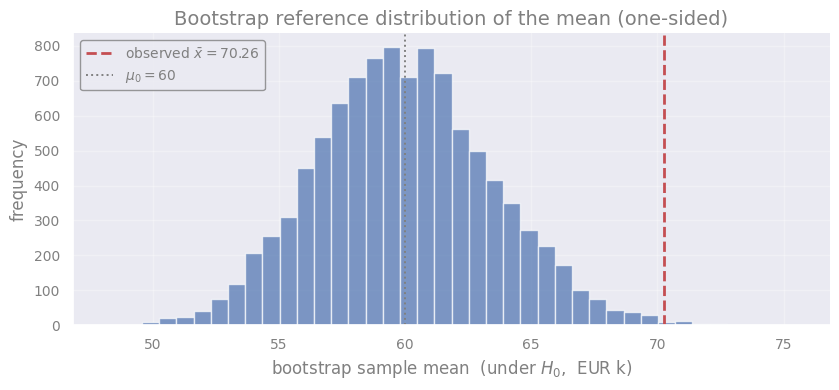

In [202]:
# Visualise the bootstrap reference distribution
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.hist(boot_T, bins=40, color="C0", alpha=0.7, edgecolor="white")

# shade the right-tail rejection region (boot_T >= x_bar)
counts, edges = np.histogram(boot_T, bins=40)
mask = edges[:-1] >= x_bar

ax.axvline(x_bar, color="C3", lw=2, ls='--', label=fr"observed $\bar x = {x_bar:.2f}$")
ax.axvline(mu0,   color="gray", lw=1.4, ls=":", label=fr"$\mu_0 = {mu0:.0f}$")
ax.set_xlabel(r"bootstrap sample mean  (under $H_0$,  EUR k)")
ax.set_ylabel("frequency")
ax.set_title("Bootstrap reference distribution of the mean (one-sided)")
ax.legend()
plt.show()

**Comment:**

The observed mean is well above the baseline of 60, and the one-sided bootstrap p-value falls below 0.05 — the data **rejects** $H_{0}$ at the 5% level. We can claim the true mean fee revenue per branch is statistically higher than the baseline.

Two things to notice:

- The reference distribution is **roughly symmetric** around $\mu_{0}$ — the Central Limit Theorem kicks in for the mean even with a heavy-tailed underlying distribution.
- The same five-step recipe would work for any other statistic — median, trimmed mean, IQR — by changing only the line that computes $T$, not the test itself.

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">

<b>[End of solution]</b>

</div>


# Limitations of p-values

<div style="border: 2px solid #ddd; border-radius: 8px; padding: 15px; background-color: #f9f9f9;">

The **p-value** is the probability, computed under $H_{0}$, of observing a test statistic <strong>at least as extreme</strong> as the one we obtained:

$$ p = P(\,|T| \geq |t_{\rm obs}|\, \mid H_{0}). \tag{13}$$

Decision rule: reject $H_{0}$ if $p < \alpha$, do not reject otherwise.

</div>


<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea">

**Common misinterpretations of the p-value — all wrong:**

_“The p-value is the probability that $H_0$ is true.”_<br>
> No. $H_0$ is a fixed claim, not a random variable.

_“A small p-value proves the alternative.”_<br>
> No. It only quantifies how surprising the data is under $H_0$.

_“A large p-value means $H_0$ is true.”_<br>
> No. It only means the data does not contradict $H_0$ strongly enough at the chosen $\alpha$.

_“The p-value measures effect size.”_<br>
> No. A trivially small effect can yield a tiny p-value with a large enough sample.</li></ul>

</div>


Two extra hazards to know about:

- **p-hacking.** Trying many tests and reporting only the smallest p-value<br>
$\rightarrow$ Chose the appropriate test <u>before</u> testing, and stick to it!


- **Multiple comparisons.** Running $m$ independent tests at $\alpha = 0.05$ inflates the chance of *at least one* false positive to roughly $1 - (1 - \alpha)^{m}$.<br>
$\rightarrow$ Corrections such as Bonferroni or FDR are the standard remedies.

<div style="border-left: 4px solid #2196F3; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #f0f8ff">

Always report <strong>three things</strong> together: the <strong>p-value</strong>, the <strong>effect size</strong> (a difference, a ratio, a Cohen's <i>d</i>), and a <strong>confidence interval</strong>.

The trio answers <em>is it real, how big is it, and how precise are we</em> — none of them alone is enough.

</div>


# Multiple Testing — When You Run Many Tests at Once

Most real-world banking work involves not **one** test but **many**.

Running $m$ independent tests at level $\alpha = 0.05$ inflates the probability of seeing **at least one** false positive — the so-called **family-wise error rate (FWER)**:

$$ \mathrm{FWER} \;=\; 1 - (1 - \alpha)^{m}. \tag{14}$$

For $m = 20$ independent tests at $\alpha = 0.05$, FWER $\approx 0.64$. **Two-thirds chance of at least one spurious result** — even when nothing is going on.

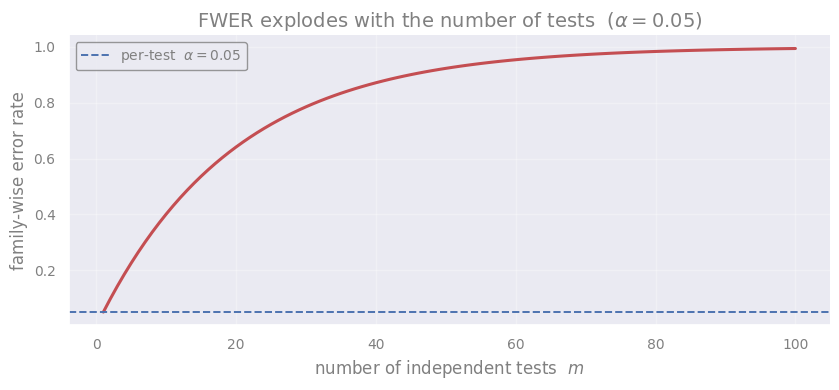

In [205]:
# ── FWER as a function of the number of tests ─────────────────────────────
alpha = 0.05
m_grid = np.arange(1, 101)
fwer = 1 - (1 - alpha) ** m_grid

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(m_grid, fwer, color="C3", lw=2.2)
ax.axhline(alpha, color="C0", ls="--", lw=1.4, label=fr"per-test  $\alpha = {alpha}$")
ax.set_xlabel(r"number of independent tests  $m$")
ax.set_ylabel("family-wise error rate")
ax.set_title(r"FWER explodes with the number of tests  ($\alpha = 0.05$)")
ax.legend()
plt.show()

<div style="border: 2px solid #ddd; border-radius: 8px; padding: 15px; background-color: #f9f9f9;">

Two standard remedies to keep multiple testing under control:

- **Bonferroni correction.**

  Declare a test significant only if its p-value is below $\alpha / m$ (instead of $\alpha$).

  $\rightarrow$ Controls the **FWER** at level $\alpha$.

- **Benjamini–Hochberg (BH) procedure for the False Discovery Rate (FDR).**

  Sort the $m$ p-values in increasing order, $p_{(1)} \leq \dots \leq p_{(m)}$. Find the largest $k$ such that

  $$ p_{(k)} \;\leq\; \frac{k}{m}\,\alpha \tag{15}$$

  and reject all hypotheses whose p-value is $\leq p_{(k)}$.

  $\rightarrow$ Controls **false discoveries among rejections** at level $\alpha$.

</div>


In [33]:
#EOF